<a href="https://colab.research.google.com/github/Gokulanandh-p/Gokulanandh-p/blob/main/LinkedIn_Data_Jobs_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
from google.colab import files
uploaded = files.upload()


Saving clean_jobs.csv to clean_jobs.csv


In [3]:
# Load the dataset into a DataFrame
df = pd.read_csv("clean_jobs.csv")

# Show first 5 rows
df.head()


,id,title,company,location,link,source,date_posted,work_type,employment_type,description
0,1,Data Analyst,Meta,"New York, NY",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-14,NaN,NaN,The Social Measurement team is a growing team ...
1,2,Data Analyst,Meta,"San Francisco, CA",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-14,NaN,NaN,The Social Measurement team is a growing team ...
2,3,Data Analyst,Meta,"Los Angeles, CA",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-14,NaN,NaN,The Social Measurement team is a growing team ...
3,4,Data Analyst,Meta,"Washington, DC",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-14,NaN,NaN,The Social Measurement team is a growing team ...
4,5,Data Analyst II,Pinterest,"Chicago, IL",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-16,NaN,NaN,About Pinterest\n\nMillions of people around t...


In [4]:
# Check basic information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048 entries, 0 to 1047
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1048 non-null   int64  
 1   title            1048 non-null   object 
 2   company          1046 non-null   object 
 3   location         1033 non-null   object 
 4   link             1048 non-null   object 
 5   source           959 non-null    object 
 6   date_posted      1025 non-null   object 
 7   work_type        0 non-null      float64
 8   employment_type  0 non-null      float64
 9   description      1044 non-null   object 
dtypes: float64(2), int64(1), object(7)
memory usage: 82.0+ KB


In [5]:
df.columns


Index(['id', 'title', 'company', 'location', 'link', 'source', 'date_posted',
       'work_type', 'employment_type', 'description'],
      dtype='object')

In [6]:
df = df.drop_duplicates()


In [8]:
df.isnull().sum()


,0
id,0
title,0
company,2
location,15
link,0
source,89
date_posted,23
work_type,1048
employment_type,1048
description,4


In [9]:
# Fill small gaps with readable text
df['company'] = df['company'].fillna('Unknown company')
df['location'] = df['location'].fillna('Not specified')
df['source'] = df['source'].fillna('Not available')
df['date_posted'] = df['date_posted'].fillna('Unknown')
df['description'] = df['description'].fillna('No description provided')

# Drop columns that are completely empty
df = df.drop(['work_type', 'employment_type'], axis=1)

# Check again to confirm cleaning
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048 entries, 0 to 1047
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           1048 non-null   int64 
 1   title        1048 non-null   object
 2   company      1048 non-null   object
 3   location     1048 non-null   object
 4   link         1048 non-null   object
 5   source       1048 non-null   object
 6   date_posted  1048 non-null   object
 7   description  1048 non-null   object
dtypes: int64(1), object(7)
memory usage: 65.6+ KB


In [10]:
df.head()


,id,title,company,location,link,source,date_posted,description
0,1,Data Analyst,Meta,"New York, NY",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-14,The Social Measurement team is a growing team ...
1,2,Data Analyst,Meta,"San Francisco, CA",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-14,The Social Measurement team is a growing team ...
2,3,Data Analyst,Meta,"Los Angeles, CA",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-14,The Social Measurement team is a growing team ...
3,4,Data Analyst,Meta,"Washington, DC",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-14,The Social Measurement team is a growing team ...
4,5,Data Analyst II,Pinterest,"Chicago, IL",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-16,About Pinterest\n\nMillions of people around t...


In [11]:
# Number of rows and columns
df.shape


(1048, 8)

In [12]:
# Most common job titles
print("Top 5 Job Titles:")
print(df['title'].value_counts().head(5))

# Most common companies hiring
print("\nTop 5 Companies hiring:")
print(df['company'].value_counts().head(5))

# Most common locations
print("\nTop 5 Locations:")
print(df['location'].value_counts().head(5))


Top 5 Job Titles:
title
Data Analyst                         152
Data Scientist                        75
Data Engineer                         58
Data Scientist, Product Analytics     29
Machine Learning Engineer             21
Name: count, dtype: int64

Top 5 Companies hiring:
company
Meta       70
Netflix    33
Amazon     18
Google     16
****       14
Name: count, dtype: int64

Top 5 Locations:
location
United States                  73
New York, NY                   65
San Francisco, CA              49
Bengaluru, Karnataka, India    40
Remote, US                     23
Name: count, dtype: int64


In [13]:
df = df[df['title'].str.contains('Data Analyst', case=False, na=False)]
print("Number of Data Analyst jobs:", len(df))


Number of Data Analyst jobs: 278


In [14]:
top_companies = df['company'].value_counts().head(10)
print("Top 10 Companies Hiring Data Analysts:")
print(top_companies)


Top 10 Companies Hiring Data Analysts:
company
Meta           12
AARATECH        8
FanDuel         5
PyjamaHR        5
LTIMindtree     4
Lensa           4
Microsoft       4
foodpanda       4
Pinterest       3
CGI             2
Name: count, dtype: int64


In [15]:
top_locations = df['location'].value_counts().head(10)
print("Top 10 Locations for Data Analyst Roles:")
print(top_locations)


Top 10 Locations for Data Analyst Roles:
location
United States                  28
New York, NY                   24
London Area, United Kingdom    10
Bengaluru, Karnataka, India     8
San Francisco, CA               7
Houston, TX                     5
Los Angeles, CA                 4
Austin, TX                      4
New York, United States         4
Chicago, IL                     4
Name: count, dtype: int64


In [16]:
skills = ['SQL', 'Python', 'Excel', 'Tableau', 'Power BI', 'R', 'Machine Learning', 'Statistics']


In [17]:
for skill in skills:
    df[skill] = df['description'].str.contains(skill, case=False, na=False)

skill_counts = df[skills].sum().sort_values(ascending=False)
print("Top Skills mentioned in job descriptions:")
print(skill_counts)


Top Skills mentioned in job descriptions:
R                   278
SQL                 232
Excel               164
Python              139
Tableau             136
Power BI            112
Statistics          104
Machine Learning     40
dtype: int64


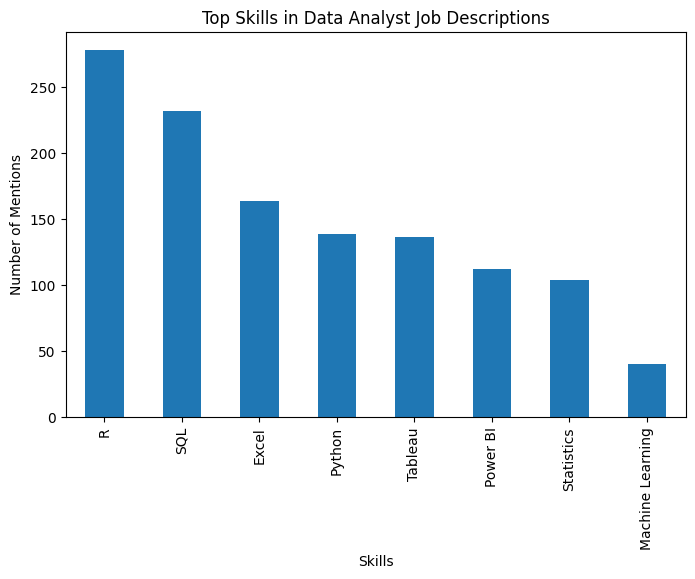

In [18]:
import matplotlib.pyplot as plt

# Skills chart
skill_counts.plot(kind='bar', figsize=(8,5))
plt.title("Top Skills in Data Analyst Job Descriptions")
plt.xlabel("Skills")
plt.ylabel("Number of Mentions")
plt.show()
